# House Price Prediction with DNN, MLP, LR

The Data Analysis (EDA) includes the below points:

*   Knowing dataset and its data.
*   Finding missing Values
*   Descriptive Statistics, unique values
*   Checking Numerical Variables
*   Identify shape
*   Plotting features against target
*   Outliers
*   Correlation between variables

In [ ]:
#importing python libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [ ]:
#importing csv file
dataset = pd.read_csv('C:/Users/Darshana Choudhary/Downloads/housing.csv')

In [ ]:
# print shape of dataset with rows and columns
print(dataset.shape)

(20640, 10)


In [ ]:
#Displaying the data from csv file imported
dataset.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
#displaying the information of the file like column_names ,its data type, etc, to get familiarized with content of the dataset:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
#all the columns have 20640 rows, except for total_bedrooms, it has 20433. That means 207 are missing values.

Descriptive Statistics

In [ ]:
dataset.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Using this, we can understand that:
1. mean distance to west is -119.56
2. mean distance to north is 35.63
3. house median age vary from 52 to 1, 12 being the mean
4. max rooms in a block are 39320, minimum 2, mean 2635
5. max total bedrooms in the block are 6445, min 1, mean 537
6. max block population is 35682, min 3, mean 1425
7. household people max 6082, min 1, mean 499
8. max income 15, min 0.5, mean 3.8
9. max median house value 500001, min 14999, mean value 206855

In [ ]:
dataset["ocean_proximity"].value_counts()
#this will give you the distibution of categories in this variable

<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

In [ ]:
unique_val= dataset.nunique()
print("Uniques values in each column are:")
print(unique_val)

Uniques values in each column are:
longitude               844
latitude                862
housing_median_age       52
total_rooms            5926
total_bedrooms         1923
population             3888
households             1815
median_income         12928
median_house_value     3842
ocean_proximity           5
dtype: int64


Finding the missing values of the dataset :
---



In [ ]:
## displaying the list of features whose values are missing:
dataset.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [ ]:
#Our data set has missing data in the column 'tota' bedrooms', which we will handle to get 0 null values.



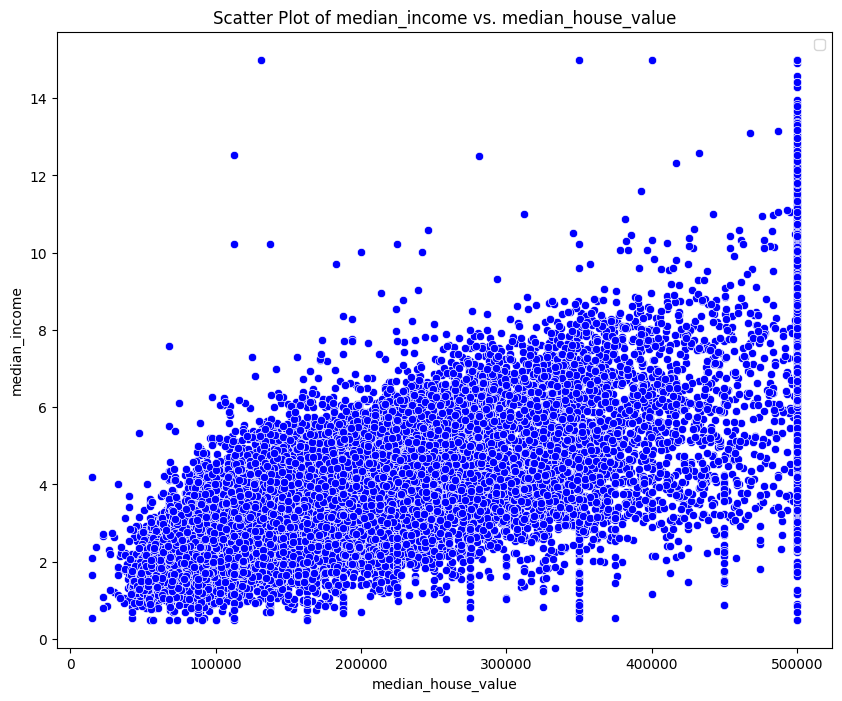

In [ ]:
# Scatter plots
plt.figure(figsize=(10, 8))
sns.scatterplot(x='median_house_value', y='median_income', data=dataset, color='blue')
plt.title('Scatter Plot of median_income vs. median_house_value')
plt.xlabel('median_house_value')
plt.ylabel('median_income')
plt.legend()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


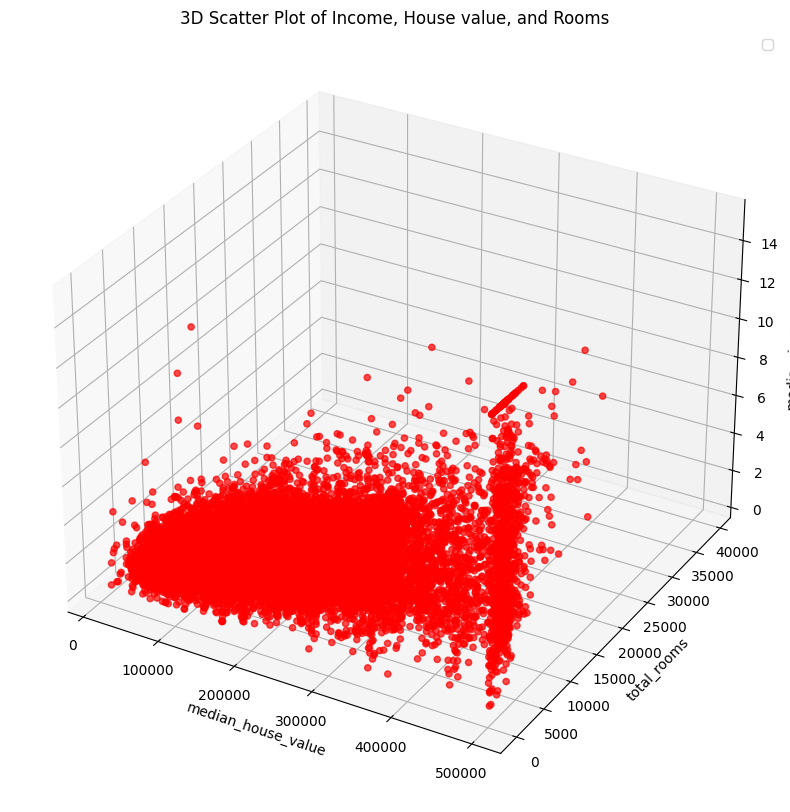

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter (dataset['median_house_value'], dataset['total_rooms'], dataset['median_income'], c='red',alpha=0.7)
# ax.scatter (may_df[ 'trip_distance 1, may_df 'fare_amount'), may_df 'passenger_count'l, c'green', label='May', alpha=0.7)
ax.set_xlabel('median_house_value')
ax.set_ylabel('total_rooms')
ax.set_zlabel('median_income')
plt.title('3D Scatter Plot of Income, House value, and Rooms')
plt.legend()
plt.show()

In [ ]:
from matplotlib import cm

norm = plt.Normalize(d['median_income'].min(),
d['median_income'].max())
colors = cm.viridis(norm(d['median_income']))
plt.show()

In [ ]:
# the above plot says common region for three entities, which are median_house_value, total_rooms and median_income. we can see
#that most data lies in median house value of 1,00,000 to 4,00,000, total rooms in the range of 10,000 to 20,000.
#The median_income range is 2000 to 5000.

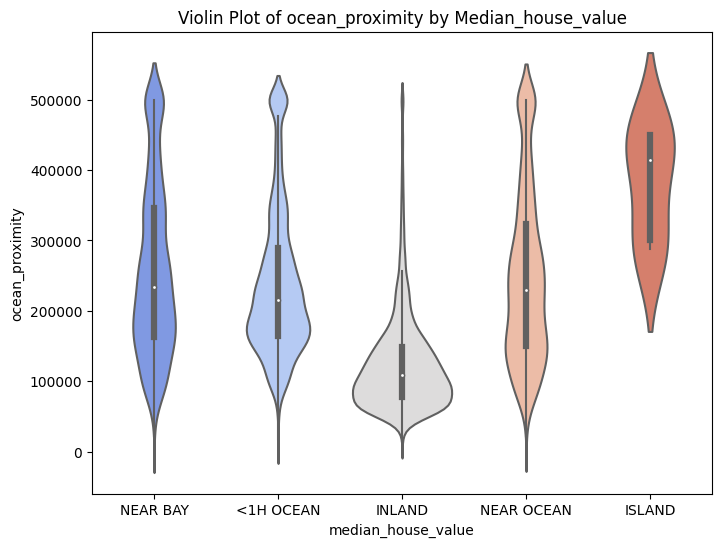

In [ ]:
# Violin plots
#for column in ('median_income','total_rooms'):
plt.figure(figsize=(8, 6))
sns.violinplot(x='ocean_proximity', y='median_house_value', data=dataset, palette='coolwarm')
plt.title(f'Violin Plot of ocean_proximity by Median_house_value')
plt.xlabel('median_house_value')
plt.ylabel('ocean_proximity')
plt.show()

Outliers:

C:\Users\Pushpak Atey\AppData\Local\Temp\ipykernel_23168\4095585079.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = dataset.quantile(0.25)
C:\Users\Pushpak Atey\AppData\Local\Temp\ipykernel_23168\4095585079.py:4: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = dataset.quantile(0.75)
C:\Users\Pushpak Atey\AppData\Local\Temp\ipykernel_23168\4095585079.py:6: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  criteria = (dataset < (Q1 - 1.5 * IQR)) | (dataset > (Q3 

Number of outliers removed: 3019


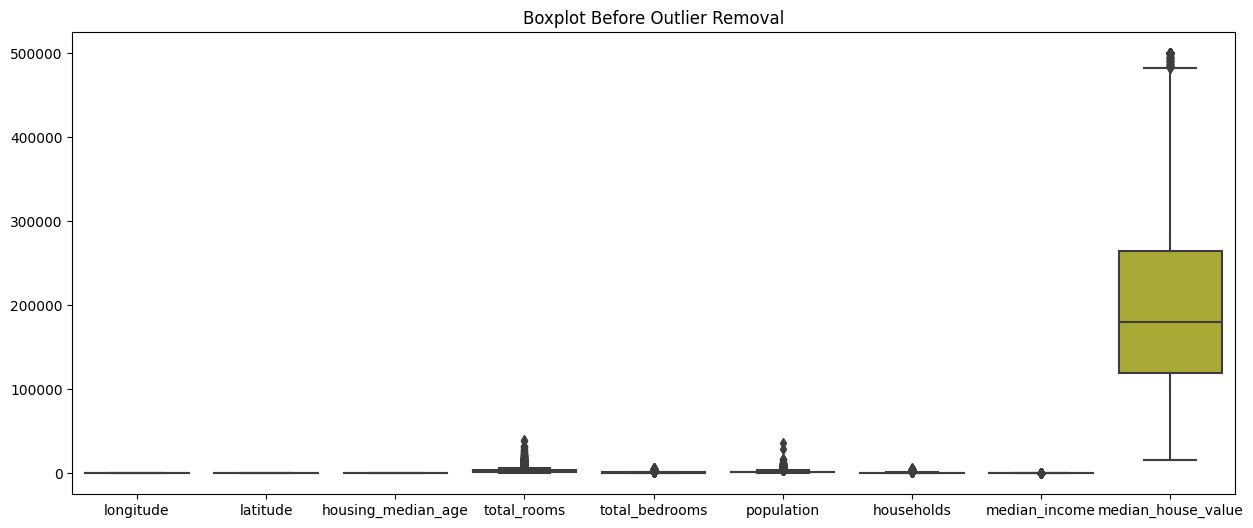

C:\Users\Pushpak Atey\AppData\Local\Temp\ipykernel_23168\4095585079.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = dataset.quantile(0.25)
C:\Users\Pushpak Atey\AppData\Local\Temp\ipykernel_23168\4095585079.py:4: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = dataset.quantile(0.75)
C:\Users\Pushpak Atey\AppData\Local\Temp\ipykernel_23168\4095585079.py:6: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  criteria = (dataset < (Q1 - 1.5 * IQR)) | (dataset > (Q3 

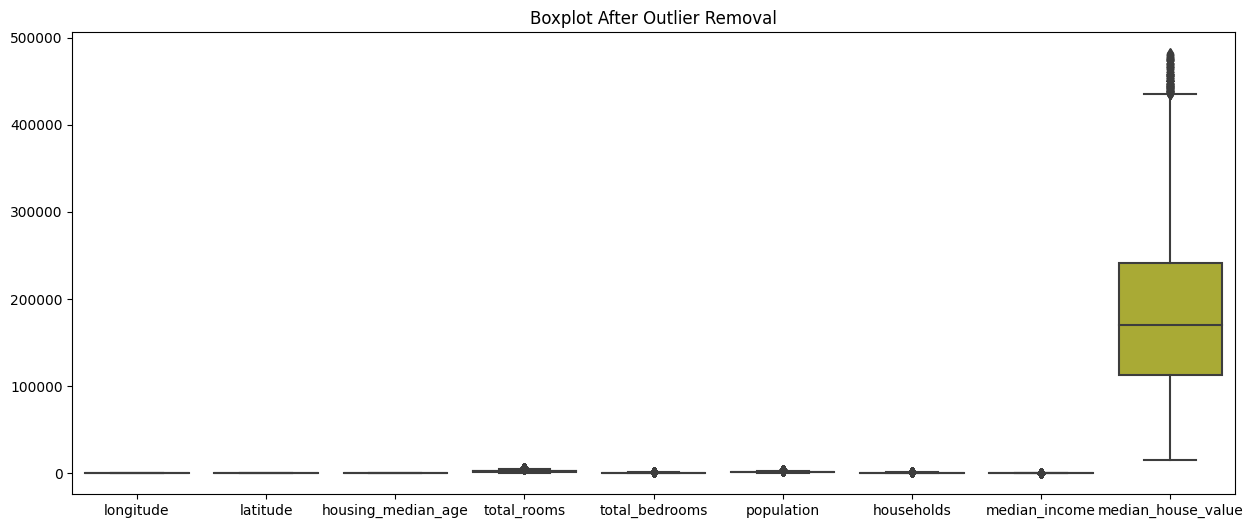

In [ ]:
# Function to remove outliers
def remove_outliers(dataset):
    Q1 = dataset.quantile(0.25)
    Q3 = dataset.quantile(0.75)
    IQR = Q3 - Q1
    criteria = (dataset < (Q1 - 1.5 * IQR)) | (dataset > (Q3 + 1.5 * IQR))
    dataset_no_outliers = dataset[~criteria.any(axis=1)]
    return dataset_no_outliers



# Before removal
initial_count = dataset.shape[0]

# Remove outliers
df_clean = remove_outliers(dataset)

# After removal
after_removal_count = df_clean.shape[0]

# Calculate the number of rows (outliers) removed
num_outliers_removed = initial_count - after_removal_count

print(f"Number of outliers removed: {num_outliers_removed}")







# Plot boxplots before outlier removal
plt.figure(figsize=(15, 6))
sns.boxplot(data=dataset)
plt.title("Boxplot Before Outlier Removal")
plt.show()

# Remove outliers
df_clean = remove_outliers(dataset)

# Plot boxplots after outlier removal
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_clean)
plt.title("Boxplot After Outlier Removal")
plt.show()

C:\Users\Pushpak Atey\AppData\Local\Temp\ipykernel_23168\1644858884.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = dataset.corr()


<AxesSubplot: >

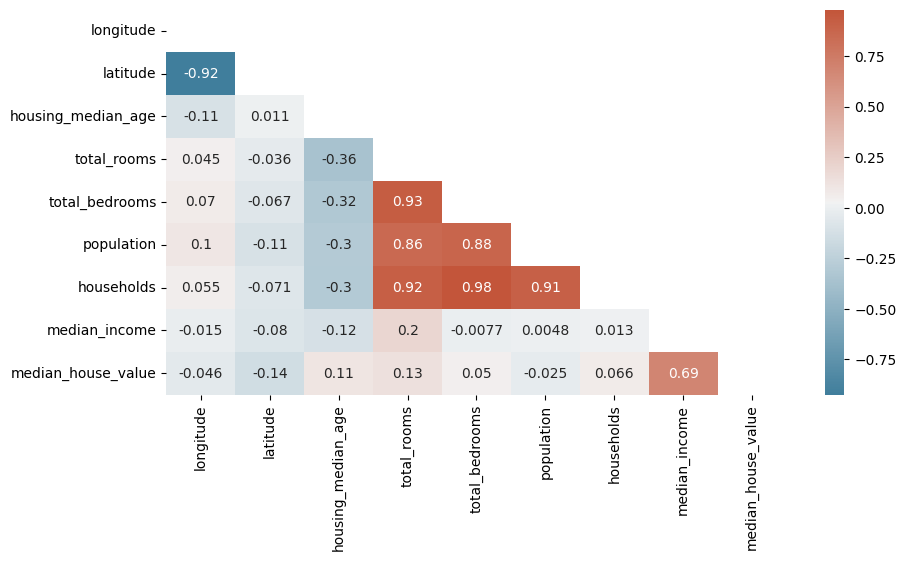

In [ ]:
# plotting heat map to find the correlation between different variables
corr = dataset.corr()
f, ax = plt.subplots(figsize=(10, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, annot=True, mask = mask, cmap=cmap)

1. Total bedrooms directly affecting total rooms, population ,households
2. The house value has significant relation with income.

C:\Users\Pushpak Atey\AppData\Local\Temp\ipykernel_23168\612178766.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  top_features = dataset.corr()[['median_house_value']].sort_values(by=['median_house_value'],ascending=False).head(30)


<AxesSubplot: >

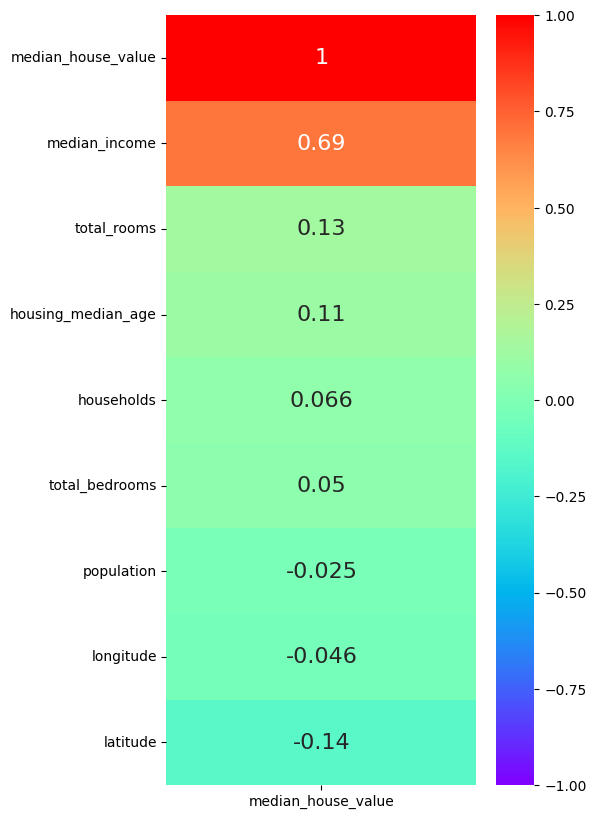

In [ ]:
top_features = dataset.corr()[['median_house_value']].sort_values(by=['median_house_value'],ascending=False).head(30)
plt.figure(figsize=(5,10))
sns.heatmap(top_features,cmap='rainbow',annot=True,annot_kws={"size": 16},vmin=-1)

In [ ]:
# house value is highly co-related to median income.
# median house value has inverse co-relation with latitude, significe as you move towards north the house prices decreases.

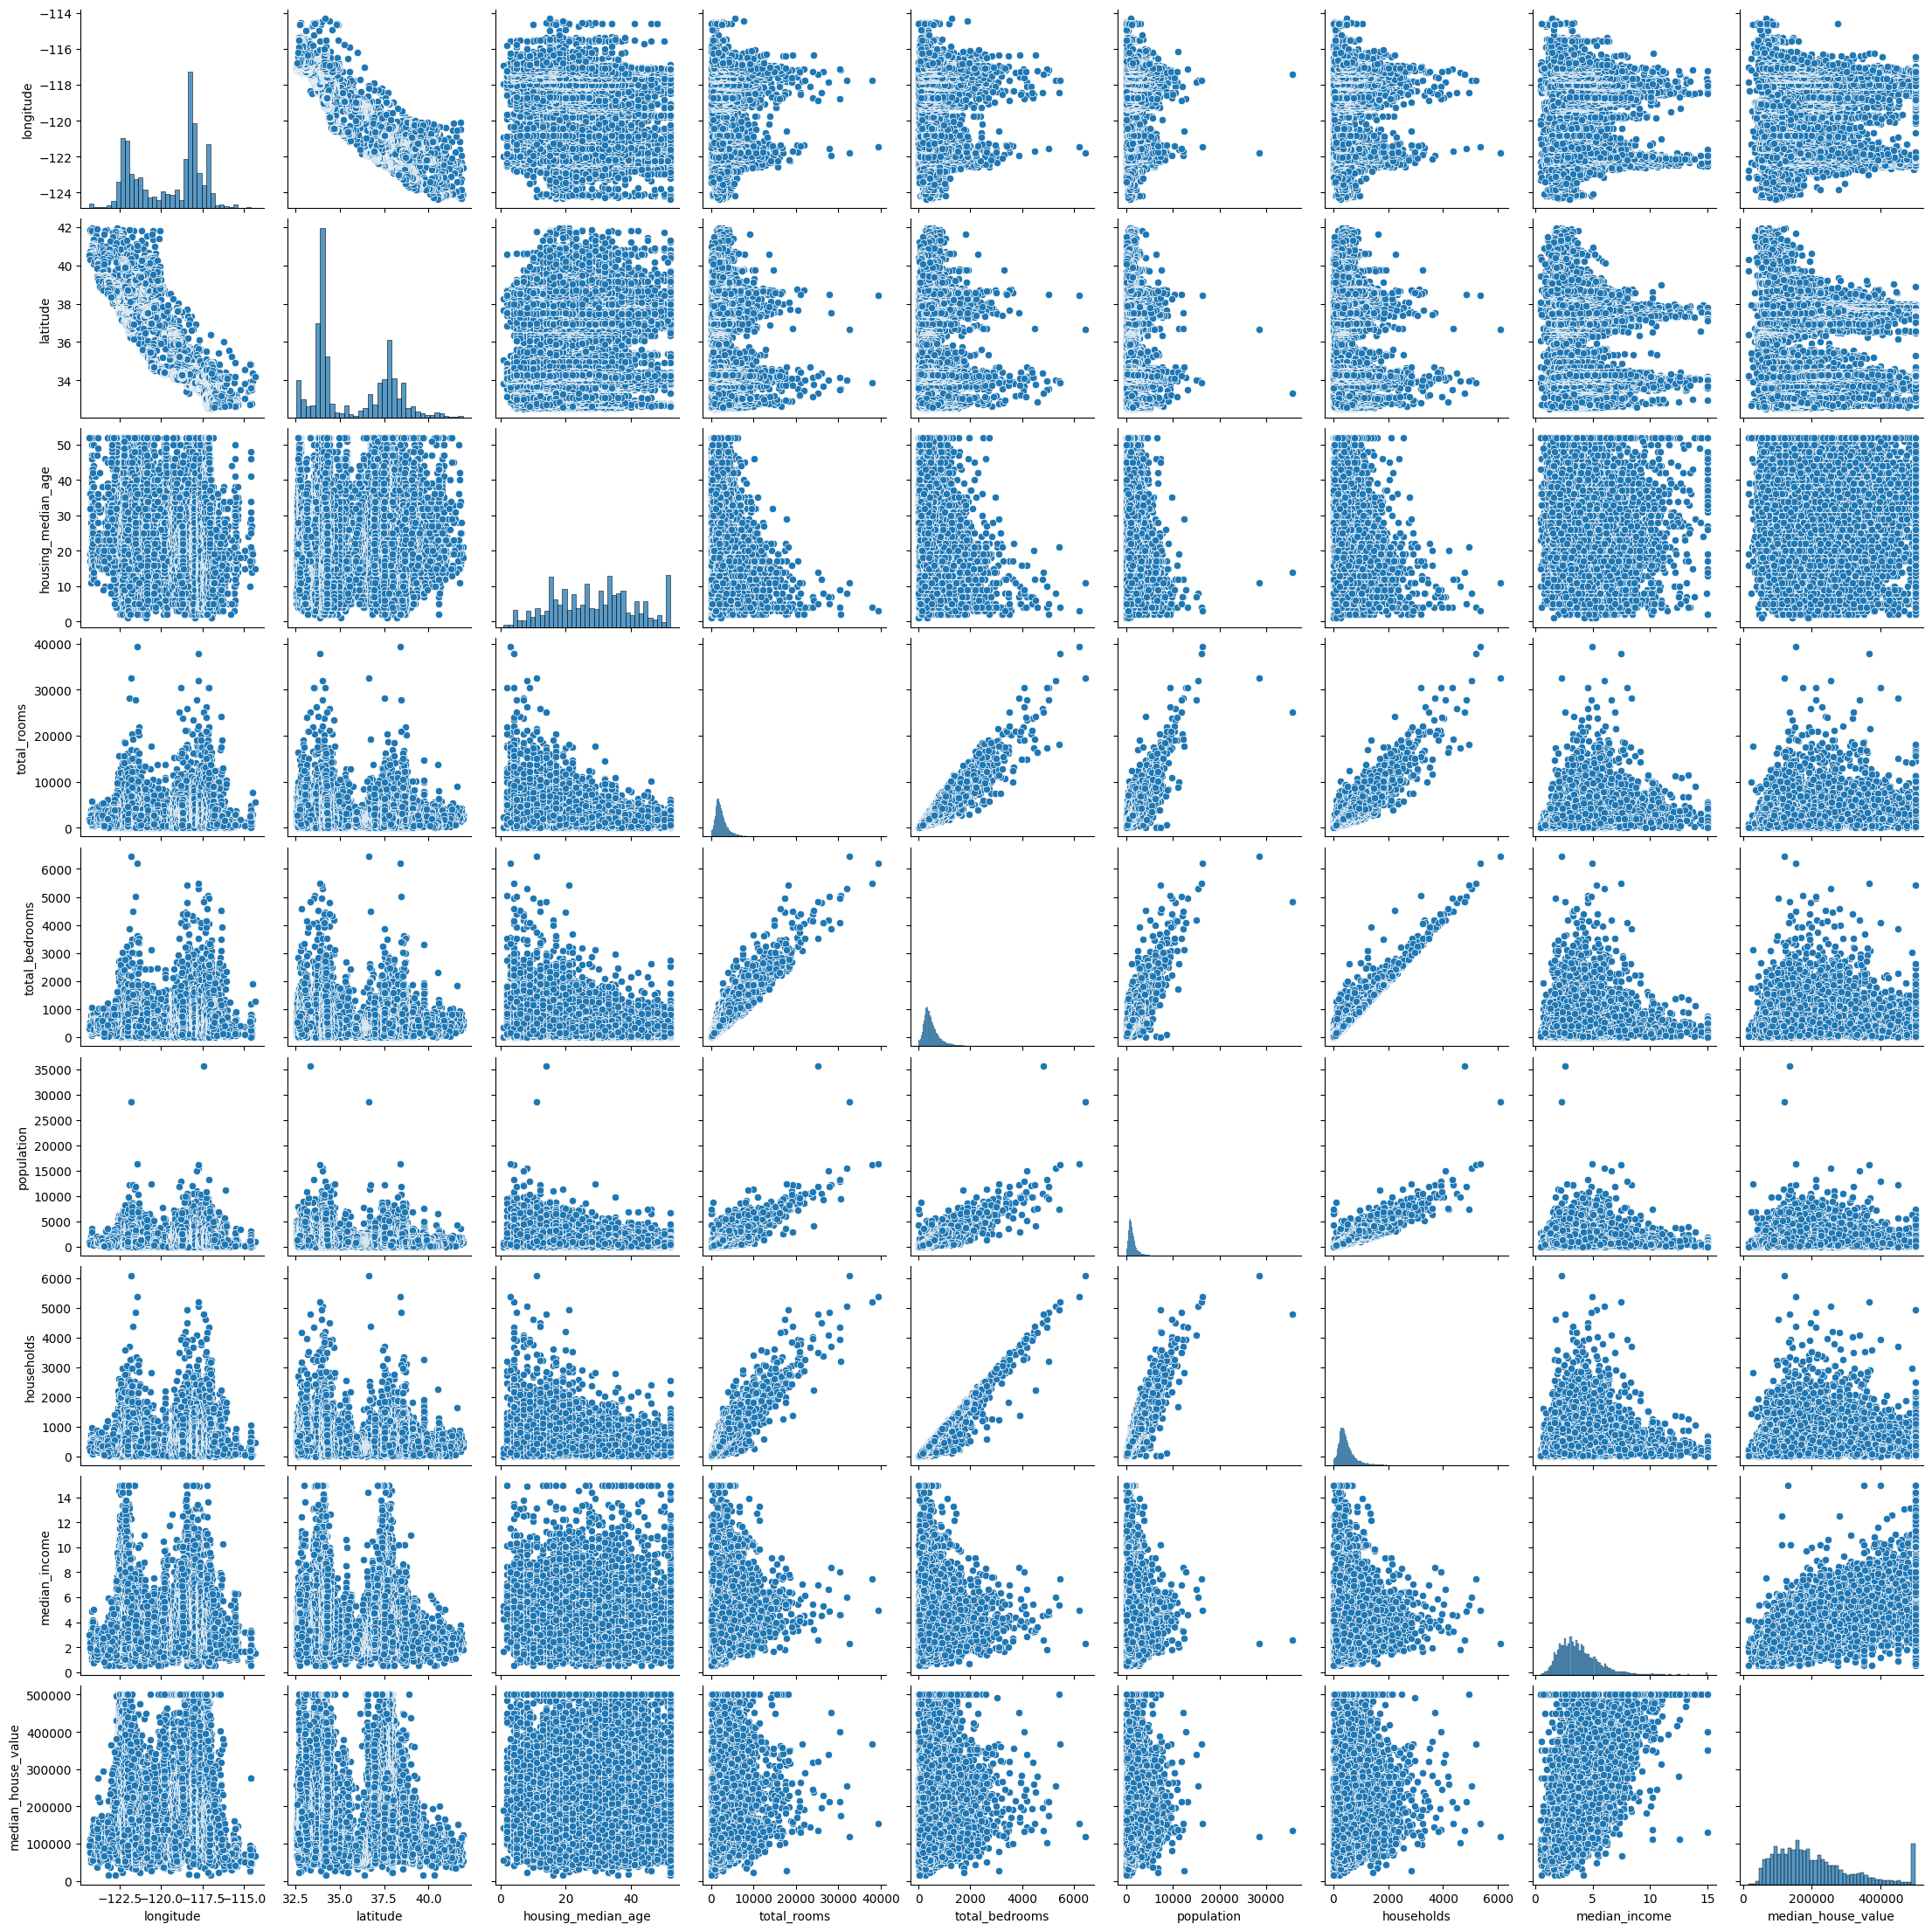

In [ ]:
#pair plot
sns.pairplot(dataset)
plt.show()


In [ ]:
#Feature Engineering

In [ ]:
d=dataset.copy()
d.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
total_bedrooms_mean = d['total_bedrooms'].mean()
print(total_bedrooms_mean)
d['total_bedrooms'] = d['total_bedrooms'].fillna(total_bedrooms_mean)

537.8705525375618


In [ ]:
#Filling missing values of 'Age' coulmn with mean value of the column

In [ ]:
#missing value check

In [ ]:
d.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

array([[<AxesSubplot: title={'center': 'longitude'}>,
        <AxesSubplot: title={'center': 'latitude'}>,
        <AxesSubplot: title={'center': 'housing_median_age'}>],
       [<AxesSubplot: title={'center': 'total_rooms'}>,
        <AxesSubplot: title={'center': 'total_bedrooms'}>,
        <AxesSubplot: title={'center': 'population'}>],
       [<AxesSubplot: title={'center': 'households'}>,
        <AxesSubplot: title={'center': 'median_income'}>,
        <AxesSubplot: title={'center': 'median_house_value'}>]],
      dtype=object)

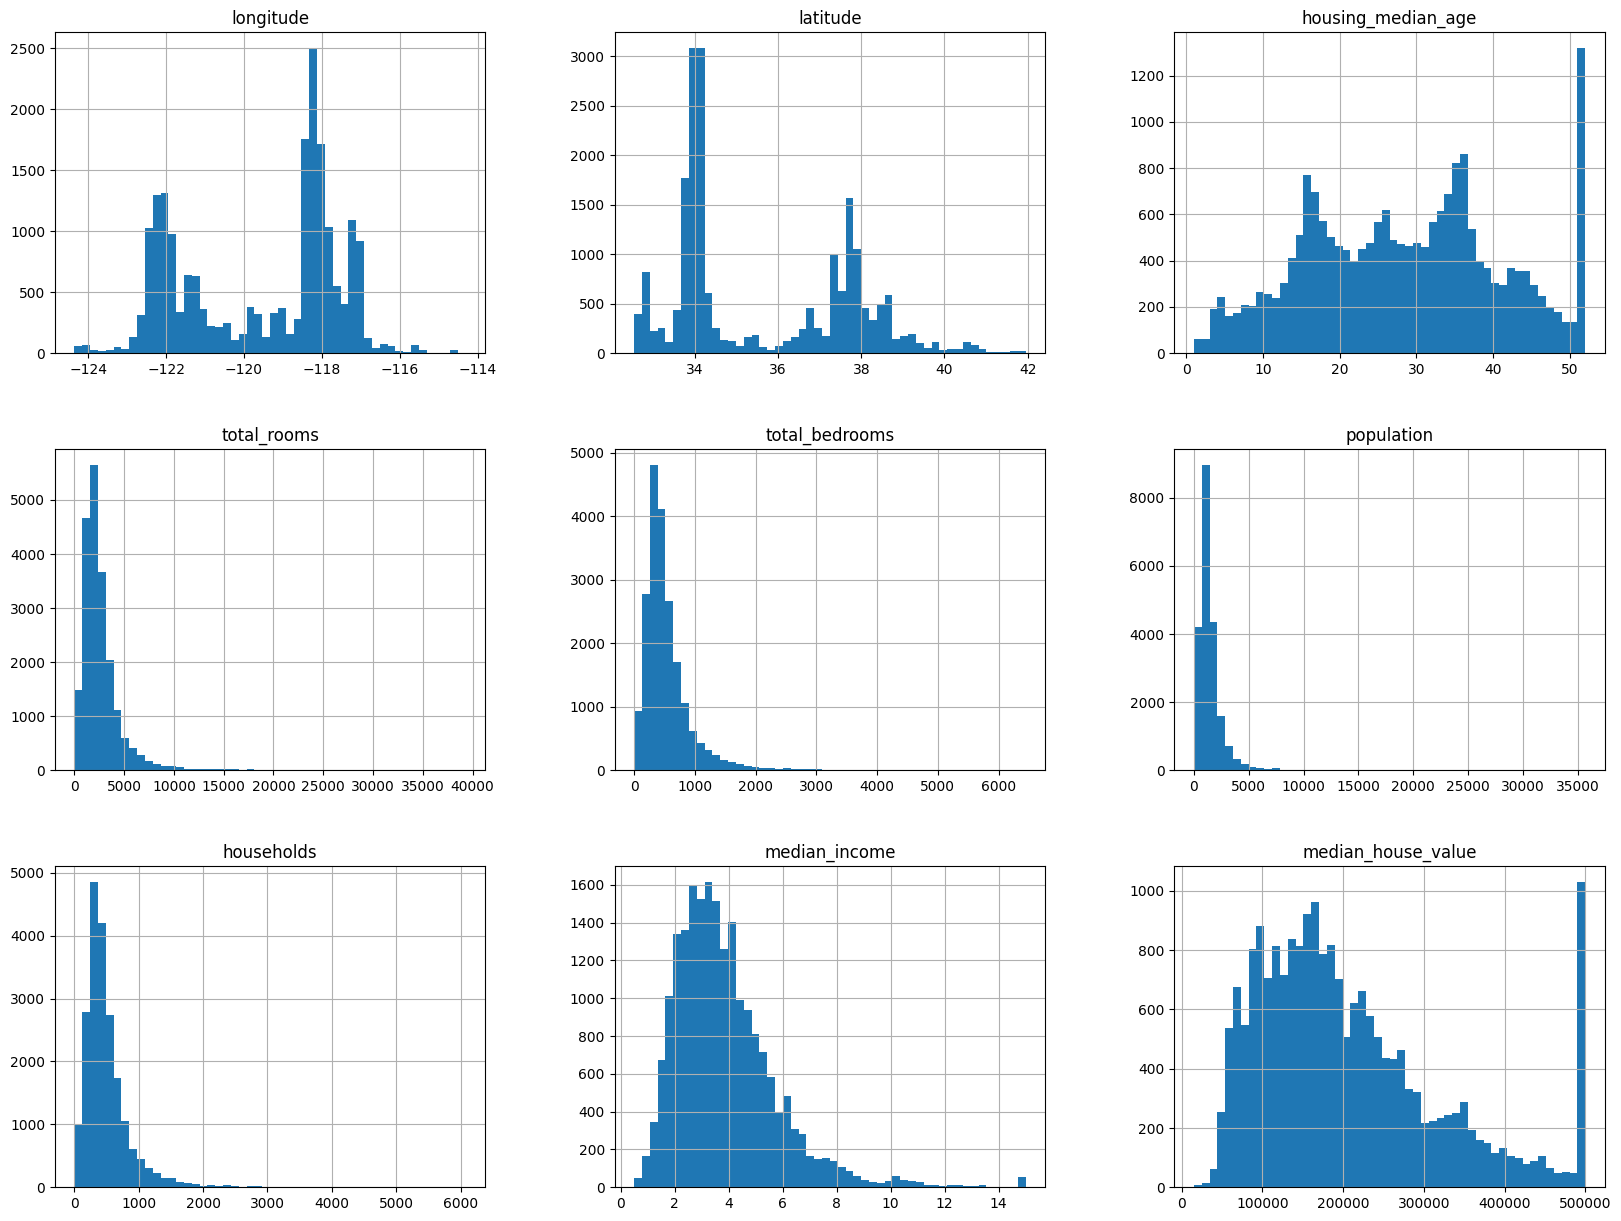

In [ ]:
dataset.hist(bins=50,figsize=(20,15))

In [ ]:
#Output: median house value has more data entities corresponding to 5,00,000 hundred thousand
# In housing median age, houses older than 50 are grouped together.

<AxesSubplot: xlabel='longitude', ylabel='latitude'>

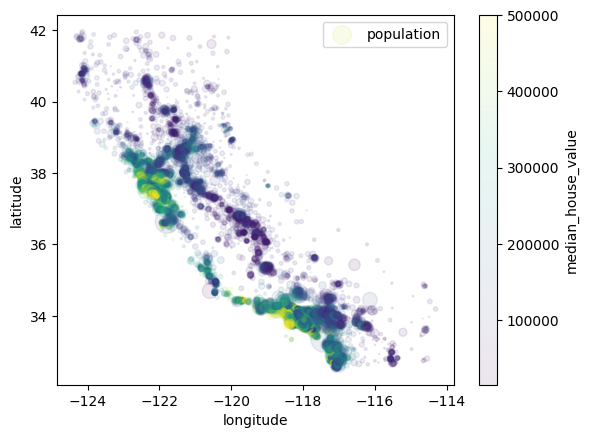

In [ ]:
d.plot(kind="scatter", x="longitude", y="latitude",
             alpha=0.1, s=d["population"]/100, label="population",
            c="median_house_value", cmap=plt.get_cmap("jet"))


#In this plot, sizes are going to represent population.
# Colours are corresponding to median_housing_value
# Below is the map of California based on longitude and latitude and also we can see the green color
#area determines higher range of house value

In [ ]:
#Label Encoding

In [ ]:
#To build machine learning model, categorical fields are needed to be converted to numerical columns for better output.

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
d[str('ocean_proximity')+'_encoded'] = le.fit_transform(d['ocean_proximity'])

In [ ]:
d=d.drop(['ocean_proximity'], axis=1)

In [ ]:
d.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_encoded
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


In [ ]:
#Preparing Model

In [ ]:
ds=d.copy()

In [ ]:
X = ds.drop('median_house_value',axis =1).values
y = ds['median_house_value'].values

#splitting Train and Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=111)

In [ ]:
# Creating a Neural Network Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam

#TensorFlow Data Validation (TFDV)

In [ ]:
!pip install tensorflow-data-validation
!pip install apache-beam



In [ ]:
!pip install --upgrade tensorflow-data-validation


In [ ]:
!pip install tensorflow-data-validation==<compatible version>


The syntax of the command is incorrect.


In [ ]:
import tensorflow as tf
import tensorflow_data_validation as tfdv


In [ ]:
# Compute Stats
stats = tfdv.generate_statistics_from_csv(data_location='C:/Users/Pushpak Atey/Downloads/housing.csv')

# Visualize the statistics
tfdv.visualize_statistics(stats)

In [ ]:

# Assuming X_train is a NumPy array
X_train_dataframe = pd.DataFrame(X_train)

# Now you can generate statistics from the DataFrame
train_stats = tfdv.generate_statistics_from_dataframe(X_train_dataframe)


In [ ]:
train_stats

datasets {
  num_examples: 16512
  features {
    type: FLOAT
    num_stats {
      common_stats {
        num_non_missing: 16512
        min_num_values: 1
        max_num_values: 1
        avg_num_values: 1.0
        num_values_histogram {
          buckets {
            low_value: 1.0
            high_value: 1.0
            sample_count: 1651.2
          }
          buckets {
            low_value: 1.0
            high_value: 1.0
            sample_count: 1651.2
          }
          buckets {
            low_value: 1.0
            high_value: 1.0
            sample_count: 1651.2
          }
          buckets {
            low_value: 1.0
            high_value: 1.0
            sample_count: 1651.2
          }
          buckets {
            low_value: 1.0
            high_value: 1.0
            sample_count: 1651.2
          }
          buckets {
            low_value: 1.0
            high_value: 1.0
            sample_count: 1651.2
          }
          buckets {
            low_val

In [ ]:
tfdv.visualize_statistics(train_stats)

In [ ]:
# Infer the schema from the statistics
schema = tfdv.infer_schema(statistics=train_stats)
schema

feature {
  name: "0"
  type: FLOAT
  presence {
    min_fraction: 1.0
    min_count: 1
  }
  shape {
    dim {
      size: 1
    }
  }
}
feature {
  name: "1"
  type: FLOAT
  presence {
    min_fraction: 1.0
    min_count: 1
  }
  shape {
    dim {
      size: 1
    }
  }
}
feature {
  name: "2"
  type: FLOAT
  presence {
    min_fraction: 1.0
    min_count: 1
  }
  shape {
    dim {
      size: 1
    }
  }
}
feature {
  name: "3"
  type: FLOAT
  presence {
    min_fraction: 1.0
    min_count: 1
  }
  shape {
    dim {
      size: 1
    }
  }
}
feature {
  name: "4"
  type: FLOAT
  presence {
    min_fraction: 1.0
    min_count: 1
  }
  shape {
    dim {
      size: 1
    }
  }
}
feature {
  name: "5"
  type: FLOAT
  presence {
    min_fraction: 1.0
    min_count: 1
  }
  shape {
    dim {
      size: 1
    }
  }
}
feature {
  name: "6"
  type: FLOAT
  presence {
    min_fraction: 1.0
    min_count: 1
  }
  shape {
    dim {
      size: 1
    }
  }
}
feature {
  name: "7"
  type: FLOA

In [ ]:
print(f"Number of features: {len(train_stats.datasets[0].features)}")
print(f"Number of examples: {train_stats.datasets[0].num_examples}")

print(f"First feature: {train_stats.datasets[0].features[0].path.step[0]}")
print(f"Last feature: {train_stats.datasets[0].features[-1].path.step[0]}")

Number of features: 9
Number of examples: 16512
First feature: 0
Last feature: 8


In [ ]:
print("Number of features in the schema: ",len(schema.feature))
print("First feature of the schema: ", schema.feature[0].name)

Number of features in the schema:  9
First feature of the schema:  0


In [ ]:
anomalies = tfdv.validate_statistics(statistics=train_stats, schema=schema)
tfdv.display_anomalies(anomalies)

# Feature Scalling



In [ ]:
#standardization scaler - fit&transform on train, fit only on test
from sklearn.preprocessing import StandardScaler
s_scaler = StandardScaler()
X_train = s_scaler.fit_transform(X_train.astype(float))
X_test = s_scaler.transform(X_test.astype(float))


In [ ]:
!pip install keras-tuner

   ---------------------------------------- 129.5/129.5 kB ? eta 0:00:00
   --------------------------------------- 950.8/950.8 kB 30.3 MB/s eta 0:00:00
   --------------------------------------- 239.8/239.8 kB 15.3 MB/s eta 0:00:00
   ---------------------------------------- 87.5/87.5 kB ? eta 0:00:00


In [ ]:
def build_model(hp):
    model = Sequential()
    for i in range(hp.Int('layers', 2, 10)):
        model.add(Dense(units=hp.Int('units_' + str(i),
                                            min_value=32,
                                            max_value=384,
                                            step=32),
                               activation='relu'))
    optimizer_choice = hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop'])

    if optimizer_choice == 'sgd':
        optimizer = SGD(hp.Choice('learning_rate_sgd', [1e-2, 1e-3, 1e-4]))
    elif optimizer_choice == 'adam':
        optimizer = Adam(hp.Choice('learning_rate_adam', [1e-2, 1e-3, 1e-4]))
    elif optimizer_choice == 'rmsprop':
        optimizer = RMSprop(hp.Choice('learning_rate_rmsprop', [1e-2, 1e-3, 1e-4]))

    model.add(Dense(1))
    model.compile(optimizer=optimizer, loss='mse', metrics=['mse'])
    return model

In [ ]:
from kerastuner.tuners import RandomSearch
tuner = RandomSearch(
    build_model,
    objective='val_mse',
    max_trials=7,
    executions_per_trial=3,
    directory='model_dir',
    project_name='House_Price_Prediction'
)

# Search using the modified data splits
tuner.search(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_test, y_test)
)

# Evaluate on the test set
best_model = tuner.get_best_models(num_models=1)[0]
loss, mse = best_model.evaluate(X_test, y_test)
print('Test Mean Squared Error:', mse)

Reloading Tuner from model_dir\House_Price_Prediction\tuner0.json
129/129 [==============================] - 1s 2ms/step - loss: 3121645824.0000 - mse: 3121645824.0000
Test Mean Squared Error: 3121645824.0


In [ ]:
print("Best Model Summary:")
print(best_model.summary())

Best Model Summary:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (32, 96)                  960       
                                                                 
 dense_1 (Dense)             (32, 32)                  3104      
                                                                 
 dense_2 (Dense)             (32, 352)                 11616     
                                                                 
 dense_3 (Dense)             (32, 64)                  22592     
                                                                 
 dense_4 (Dense)             (32, 256)                 16640     
                                                                 
 dense_5 (Dense)             (32, 1)                   257       
                                                                 
Total params: 55169 (215.50 KB)
Trai

In [ ]:
tuner.results_summary()

Results summary
Results in model_dir\House_Price_Prediction
Showing 10 best trials
Objective(name="val_mse", direction="min")

Trial 1 summary
Hyperparameters:
layers: 5
units_0: 96
units_1: 32
optimizer: adam
learning_rate_adam: 0.01
units_2: 352
units_3: 64
units_4: 256
units_5: 320
units_6: 32
units_7: 160
units_8: 32
Score: 3192902314.6666665

Trial 4 summary
Hyperparameters:
layers: 4
units_0: 384
units_1: 256
optimizer: adam
learning_rate_adam: 0.001
units_2: 256
units_3: 160
units_4: 352
units_5: 320
units_6: 64
units_7: 288
units_8: 128
Score: 3691286272.0

Trial 2 summary
Hyperparameters:
layers: 2
units_0: 64
units_1: 32
optimizer: adam
learning_rate_adam: 0.01
units_2: 128
units_3: 32
units_4: 192
units_5: 96
units_6: 384
units_7: 192
units_8: 160
Score: 4194994858.6666665

Trial 5 summary
Hyperparameters:
layers: 4
units_0: 160
units_1: 192
optimizer: adam
learning_rate_adam: 0.0001
units_2: 320
units_3: 160
units_4: 256
units_5: 320
units_6: 288
units_7: 96
units_8: 32
Sco

In [ ]:
#MLP (Multi-Layer Perceptron)

In [ ]:
mlp_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Compile the model
mlp_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
mlp_model.fit(X_train, y_train, epochs=100, batch_size=32,validation_data=(X_test, y_test), validation_split=0.1)

Epoch 1/100
516/516 [==============================] - 2s 2ms/step - loss: 55677743104.0000 - val_loss: 56141344768.0000
Epoch 2/100
516/516 [==============================] - 1s 2ms/step - loss: 52871020544.0000 - val_loss: 50763837440.0000
Epoch 3/100
516/516 [==============================] - 1s 2ms/step - loss: 44682399744.0000 - val_loss: 39887790080.0000
Epoch 4/100
516/516 [==============================] - 1s 2ms/step - loss: 32928108544.0000 - val_loss: 27504953344.0000
Epoch 5/100
516/516 [==============================] - 1s 2ms/step - loss: 21984311296.0000 - val_loss: 17903114240.0000
Epoch 6/100
516/516 [==============================] - 1s 2ms/step - loss: 14946387968.0000 - val_loss: 12971802624.0000
Epoch 7/100
516/516 [==============================] - 1s 2ms/step - loss: 11796789248.0000 - val_loss: 11054725120.0000
Epoch 8/100
516/516 [==============================] - 1s 2ms/step - loss: 10452410368.0000 - val_loss: 10100858880.0000
Epoch 9/100
516/516 [===========

<AxesSubplot: >

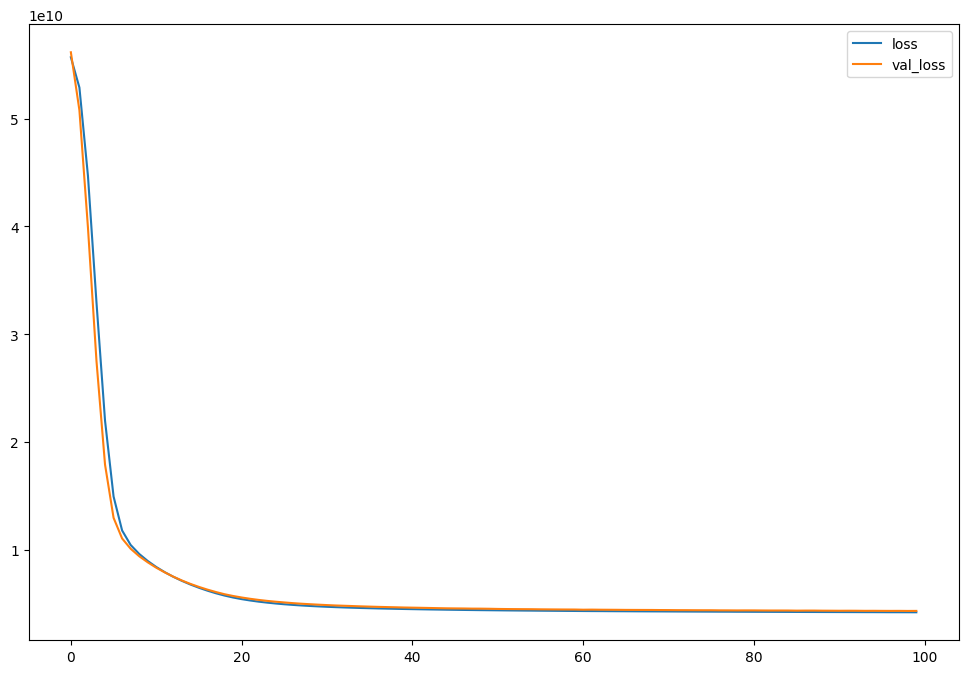

In [ ]:
loss_df = pd.DataFrame(mlp_model.history.history)
loss_df.plot(figsize=(12,8))

In [ ]:
# Evaluate MLP model
mlp_y_pred = mlp_model.predict(X_test)
mlp_y_pred_1d = mlp_y_pred.flatten()
# result = pd.DataFrame(mlp_y_pred,columns=['median_house_value'])
# result
res_mlp = pd.DataFrame({'Actual' : y_test, 'Predicted' : mlp_y_pred_1d})
res_mlp

129/129 [==============================] - 0s 1ms/step


,Actual,Predicted
0,275000.0,145891.109375
1,79800.0,123806.679688
2,96000.0,181976.750000
3,99600.0,139997.250000
4,133000.0,150695.781250
...,...,...
4123,111400.0,128496.890625
4124,434500.0,366461.781250
4125,174300.0,127916.804688
4126,220800.0,213258.218750


In [ ]:
from sklearn import metrics
print('For Multi-Layer Perceptron (MLP):')
print('Mean Absolute Error: {:.2f}'.format(metrics.mean_absolute_error(y_test, mlp_y_pred)))
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(y_test, mlp_y_pred)))
print('Root Mean Squared Error: {:.2f}'.format(np.sqrt(metrics.mean_squared_error(y_test, mlp_y_pred))))
print('Variance score is: {:.2f}'.format(metrics.explained_variance_score(y_test,mlp_y_pred)))

For Multi-Layer Perceptron (MLP):
Mean Absolute Error: 46134.91
Mean Squared Error: 4337013896.04
Root Mean Squared Error: 65856.01
Variance score is: 0.68


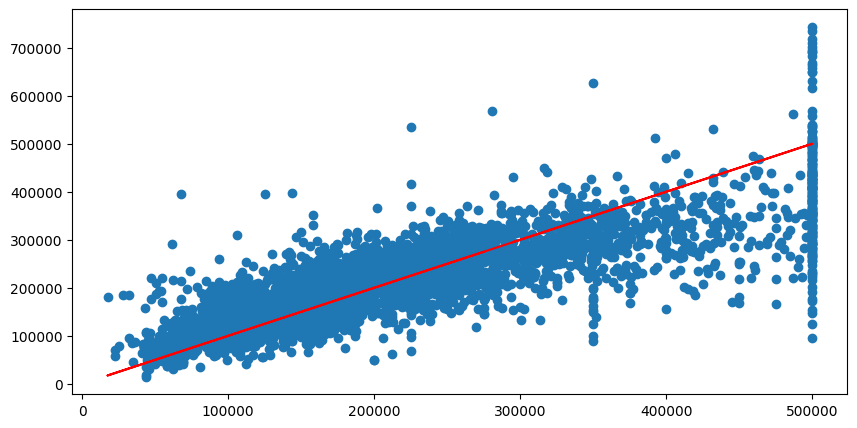

In [ ]:
# Our predictions
fig = plt.figure(figsize=(10,5))
plt.scatter(y_test,mlp_y_pred)
# Perfect predictions
plt.plot(y_test,y_test,'r')

In [ ]:
mlp_model = Sequential([
    Dense(224, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(96, activation='relu'),
    Dense(256, activation='relu'),
    Dense(416, activation='relu'),
    Dense(96, activation='relu'),
    Dense(480, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Compile the model
mlp_model.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error')

# Train the model
mlp_model.fit(X_train, y_train, epochs=100, batch_size=32,validation_data=(X_test, y_test), validation_split=0.1)

Epoch 1/100
516/516 [==============================] - 3s 4ms/step - loss: 6715399168.0000 - val_loss: 6357614080.0000
Epoch 2/100
516/516 [==============================] - 2s 4ms/step - loss: 4727066112.0000 - val_loss: 4132582912.0000
Epoch 3/100
516/516 [==============================] - 2s 4ms/step - loss: 4304525824.0000 - val_loss: 3685752576.0000
Epoch 4/100
516/516 [==============================] - 2s 4ms/step - loss: 4049805312.0000 - val_loss: 3929650688.0000
Epoch 5/100
516/516 [==============================] - 2s 4ms/step - loss: 3905740032.0000 - val_loss: 3557044992.0000
Epoch 6/100
516/516 [==============================] - 2s 4ms/step - loss: 3677475840.0000 - val_loss: 3711555072.0000
Epoch 7/100
516/516 [==============================] - 2s 4ms/step - loss: 3657828608.0000 - val_loss: 4466037248.0000
Epoch 8/100
516/516 [==============================] - 2s 4ms/step - loss: 3575118336.0000 - val_loss: 3935767808.0000
Epoch 9/100
516/516 [===========================

In [ ]:
mlp_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 224)               2240      
                                                                 
 dense_10 (Dense)            (None, 96)                21600     
                                                                 
 dense_11 (Dense)            (None, 256)               24832     
                                                                 
 dense_12 (Dense)            (None, 416)               106912    
                                                                 
 dense_13 (Dense)            (None, 96)                40032     
                                                                 
 dense_14 (Dense)            (None, 480)               46560     
                                                                 
 dense_15 (Dense)            (None, 1)                

<AxesSubplot: >

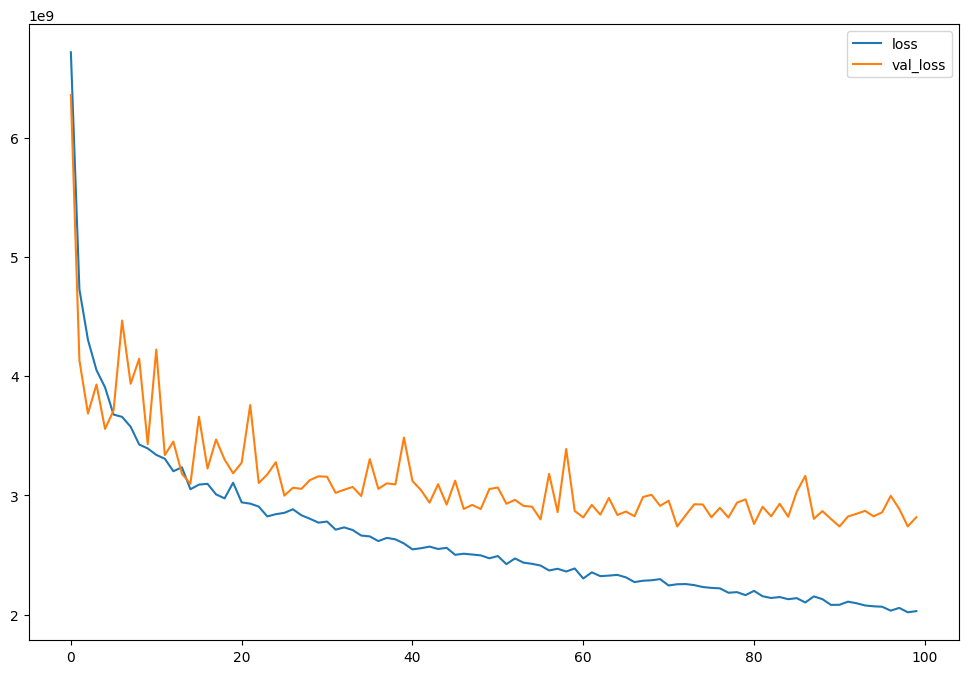

In [ ]:
loss_df = pd.DataFrame(mlp_model.history.history)
loss_df.plot(figsize=(12,8))

In [ ]:
# Evaluate MLP model
mlp_y_pred = mlp_model.predict(X_test)
mlp_y_pred_1d = mlp_y_pred.flatten()
# result = pd.DataFrame(mlp_y_pred,columns=['median_house_value'])
# result
res_mlp = pd.DataFrame({'Actual' : y_test, 'Predicted' : mlp_y_pred_1d})
res_mlp

129/129 [==============================] - 0s 2ms/step


,Actual,Predicted
0,275000.0,229232.765625
1,79800.0,81394.789062
2,96000.0,154945.953125
3,99600.0,114126.515625
4,133000.0,173689.671875
...,...,...
4123,111400.0,104564.335938
4124,434500.0,448193.656250
4125,174300.0,176648.218750
4126,220800.0,239135.328125


In [ ]:
from sklearn import metrics
print('For Multi-Layer Perceptron (MLP):')
print('Mean Absolute Error: {:.2f}'.format(metrics.mean_absolute_error(y_test, mlp_y_pred)))
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(y_test, mlp_y_pred)))
print('Root Mean Squared Error: {:.2f}'.format(np.sqrt(metrics.mean_squared_error(y_test, mlp_y_pred))))
print('Variance score is: {:.2f}'.format(metrics.explained_variance_score(y_test,mlp_y_pred)))

For Multi-Layer Perceptron (MLP):
Mean Absolute Error: 35546.67
Mean Squared Error: 2816690374.66
Root Mean Squared Error: 53072.50
Variance score is: 0.79


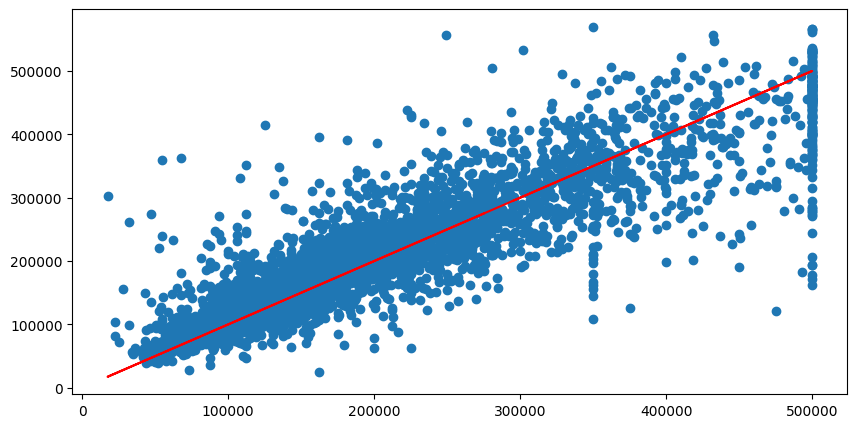

In [ ]:
# Our predictions
fig = plt.figure(figsize=(10,5))
plt.scatter(y_test,mlp_y_pred)
# Perfect predictions
plt.plot(y_test,y_test,'r')

In [ ]:
mlp_model = Sequential([
    Dense(224, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(96, activation='relu'),
    Dense(256, activation='relu'),
    Dense(416, activation='relu'),
    Dense(96, activation='relu'),
    Dense(480, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Compile the model
mlp_model.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error')

# Train the model
mlp_model.fit(X_train, y_train, epochs=100, batch_size=32,validation_data=(X_test, y_test), validation_split=0.1)

Epoch 1/100
516/516 [==============================] - 3s 4ms/step - loss: 6590192640.0000 - val_loss: 4713992704.0000
Epoch 2/100
516/516 [==============================] - 2s 3ms/step - loss: 4691112960.0000 - val_loss: 4064322048.0000
Epoch 3/100
516/516 [==============================] - 2s 3ms/step - loss: 4192396544.0000 - val_loss: 4412744192.0000
Epoch 4/100
516/516 [==============================] - 2s 4ms/step - loss: 4221481472.0000 - val_loss: 4177149184.0000
Epoch 5/100
516/516 [==============================] - 2s 4ms/step - loss: 3723574528.0000 - val_loss: 4611062784.0000
Epoch 6/100
516/516 [==============================] - 2s 4ms/step - loss: 3672147456.0000 - val_loss: 3464065024.0000
Epoch 7/100
516/516 [==============================] - 2s 3ms/step - loss: 3493954048.0000 - val_loss: 3595399936.0000
Epoch 8/100
516/516 [==============================] - 2s 4ms/step - loss: 3473133312.0000 - val_loss: 3678040832.0000
Epoch 9/100
516/516 [===========================

In [ ]:
mlp_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 224)               2240      
                                                                 
 dense_17 (Dense)            (None, 96)                21600     
                                                                 
 dense_18 (Dense)            (None, 256)               24832     
                                                                 
 dense_19 (Dense)            (None, 416)               106912    
                                                                 
 dense_20 (Dense)            (None, 96)                40032     
                                                                 
 dense_21 (Dense)            (None, 480)               46560     
                                                                 
 dense_22 (Dense)            (None, 1)                

<AxesSubplot: >

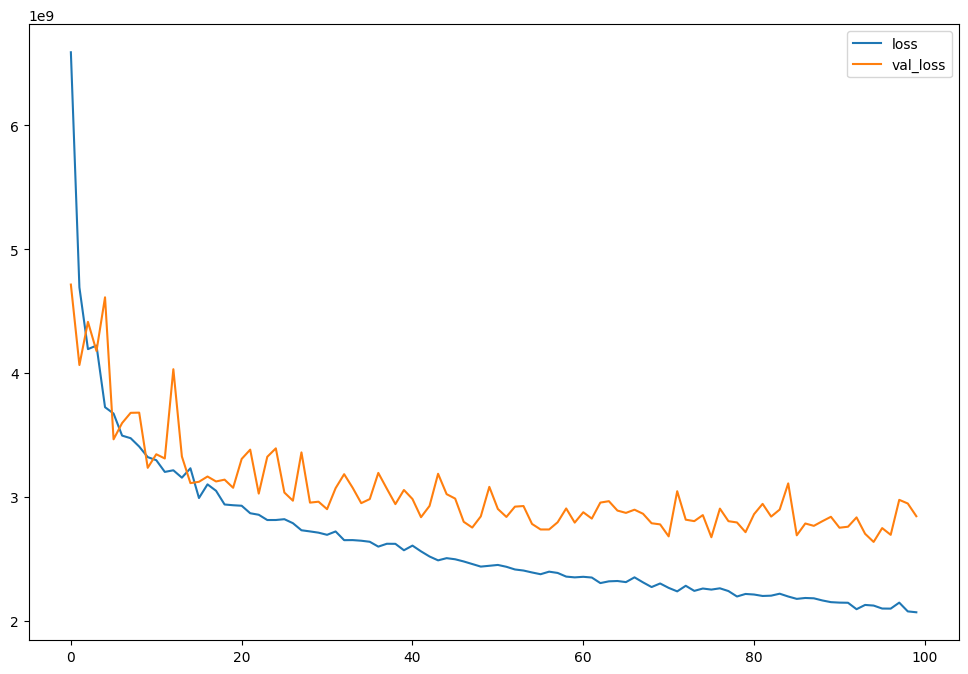

In [ ]:
loss_df = pd.DataFrame(mlp_model.history.history)
loss_df.plot(figsize=(12,8))

In [ ]:
#Evaluate MLP model
mlp_y_pred = mlp_model.predict(X_test)
mlp_y_pred_1d = mlp_y_pred.flatten()
# result = pd.DataFrame(mlp_y_pred,columns=['median_house_value'])
# result
res_mlp = pd.DataFrame({'Actual' : y_test, 'Predicted' : mlp_y_pred_1d})
res_mlp

129/129 [==============================] - 0s 2ms/step


,Actual,Predicted
0,275000.0,203182.562500
1,79800.0,77887.859375
2,96000.0,125837.976562
3,99600.0,95066.343750
4,133000.0,168489.734375
...,...,...
4123,111400.0,73373.421875
4124,434500.0,374116.750000
4125,174300.0,170467.671875
4126,220800.0,192107.640625


In [ ]:
from sklearn import metrics
print('For Multi-Layer Perceptron (MLP):')
print('Mean Absolute Error: {:.2f}'.format(metrics.mean_absolute_error(y_test, mlp_y_pred)))
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(y_test, mlp_y_pred)))
print('Root Mean Squared Error: {:.2f}'.format(np.sqrt(metrics.mean_squared_error(y_test, mlp_y_pred))))
print('Variance score is: {:.2f}'.format(metrics.explained_variance_score(y_test,mlp_y_pred)))

For Multi-Layer Perceptron (MLP):
Mean Absolute Error: 34393.08
Mean Squared Error: 2842982263.17
Root Mean Squared Error: 53319.62
Variance score is: 0.79


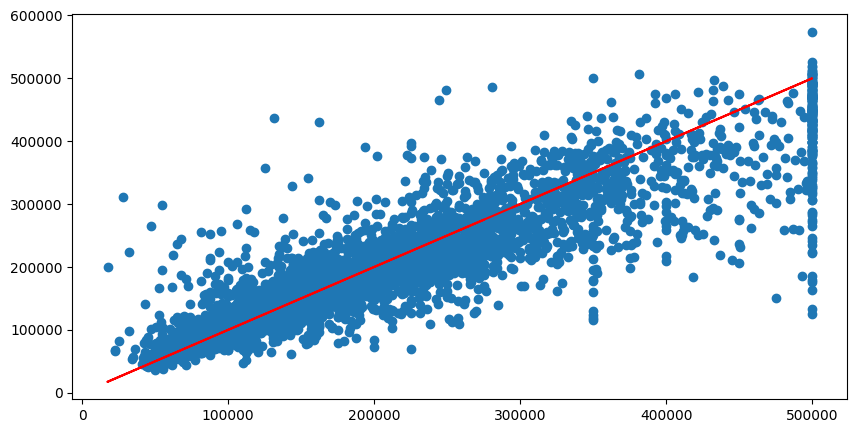

In [ ]:
# Our predictions
fig = plt.figure(figsize=(10,5))
plt.scatter(y_test,mlp_y_pred)
# Perfect predictions
plt.plot(y_test,y_test,'r')

In [ ]:
# Build the Linear Regression model
from sklearn.linear_model import LinearRegression

linear_model = Sequential([
    Dense(1, input_dim=X_train.shape[1], activation='linear')
])

# Compile the model
linear_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
linear_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test,y_test), validation_split=0.1)

Epoch 1/100
516/516 [==============================] - 1s 2ms/step - loss: 55883243520.0000 - val_loss: 56990035968.0000
Epoch 2/100
516/516 [==============================] - 1s 2ms/step - loss: 55882932224.0000 - val_loss: 56989765632.0000
Epoch 3/100
516/516 [==============================] - 1s 2ms/step - loss: 55882641408.0000 - val_loss: 56989450240.0000
Epoch 4/100
516/516 [==============================] - 1s 1ms/step - loss: 55882326016.0000 - val_loss: 56989155328.0000
Epoch 5/100
516/516 [==============================] - 1s 2ms/step - loss: 55882063872.0000 - val_loss: 56988860416.0000
Epoch 6/100
516/516 [==============================] - 1s 1ms/step - loss: 55881764864.0000 - val_loss: 56988561408.0000
Epoch 7/100
516/516 [==============================] - 1s 1ms/step - loss: 55881445376.0000 - val_loss: 56988262400.0000
Epoch 8/100
516/516 [==============================] - 1s 1ms/step - loss: 55881138176.0000 - val_loss: 56987942912.0000
Epoch 9/100
516/516 [===========

In [ ]:
linear_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_23 (Dense)            (None, 1)                 10        
                                                                 
Total params: 10 (40.00 Byte)
Trainable params: 10 (40.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


<AxesSubplot: >

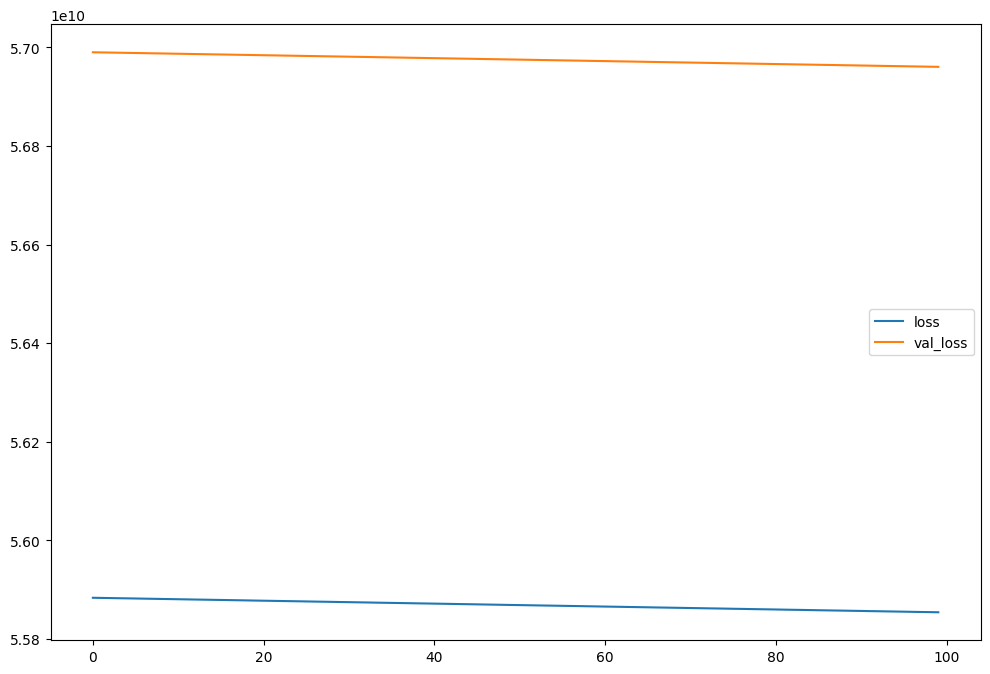

In [ ]:
loss_df = pd.DataFrame(linear_model.history.history)
loss_df.plot(figsize=(12,8))

In [ ]:
# Evaluate Linear Regression model
linear_y_pred = linear_model.predict(X_test)

129/129 [==============================] - 0s 1ms/step


In [ ]:
from sklearn import metrics
print('For Linear Regression:')
print('Mean Absolute Error: {:.2f}'.format(metrics.mean_absolute_error(y_test, linear_y_pred)))
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(y_test, linear_y_pred)))
print('Root Mean Squared Error: {:.2f}'.format(np.sqrt(metrics.mean_squared_error(y_test, linear_y_pred))))
print('Variance score is: {:.2f}'.format(metrics.explained_variance_score(y_test,linear_y_pred)))


For Linear Regression:
Mean Absolute Error: 208768.47
Mean Squared Error: 56960485763.62
Root Mean Squared Error: 238663.96
Variance score is: 0.00


In [ ]:
#DNN

In [ ]:
model = Sequential()

model.add(Dense(224,activation='relu'))
model.add(Dense(96,activation='relu'))
model.add(Dense(256,activation='relu'))
model.add(Dense(416,activation='relu'))
model.add(Dense(96,activation='relu'))
model.add(Dense(480,activation='relu'))
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.01),loss='mse')

In [ ]:
model.fit(x=X_train,y=y_train,
          validation_data=(X_test,y_test),
          batch_size=32,epochs=100)

Epoch 1/100
516/516 [==============================] - 3s 4ms/step - loss: 6351854080.0000 - val_loss: 6962831872.0000
Epoch 2/100
516/516 [==============================] - 2s 4ms/step - loss: 4830472192.0000 - val_loss: 4417691136.0000
Epoch 3/100
516/516 [==============================] - 2s 4ms/step - loss: 4064439296.0000 - val_loss: 4279926528.0000
Epoch 4/100
516/516 [==============================] - 2s 4ms/step - loss: 4127618304.0000 - val_loss: 3784568320.0000
Epoch 5/100
516/516 [==============================] - 2s 4ms/step - loss: 3737296384.0000 - val_loss: 3632637952.0000
Epoch 6/100
516/516 [==============================] - 2s 4ms/step - loss: 3660237824.0000 - val_loss: 3702201344.0000
Epoch 7/100
516/516 [==============================] - 2s 4ms/step - loss: 3728182528.0000 - val_loss: 3618140928.0000
Epoch 8/100
516/516 [==============================] - 2s 4ms/step - loss: 3446369792.0000 - val_loss: 3951886592.0000
Epoch 9/100
516/516 [===========================

In [ ]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_24 (Dense)            (32, 224)                 2240      
                                                                 
 dense_25 (Dense)            (32, 96)                  21600     
                                                                 
 dense_26 (Dense)            (32, 256)                 24832     
                                                                 
 dense_27 (Dense)            (32, 416)                 106912    
                                                                 
 dense_28 (Dense)            (32, 96)                  40032     
                                                                 
 dense_29 (Dense)            (32, 480)                 46560     
                                                                 
 dense_30 (Dense)            (32, 1)                  

<AxesSubplot: >

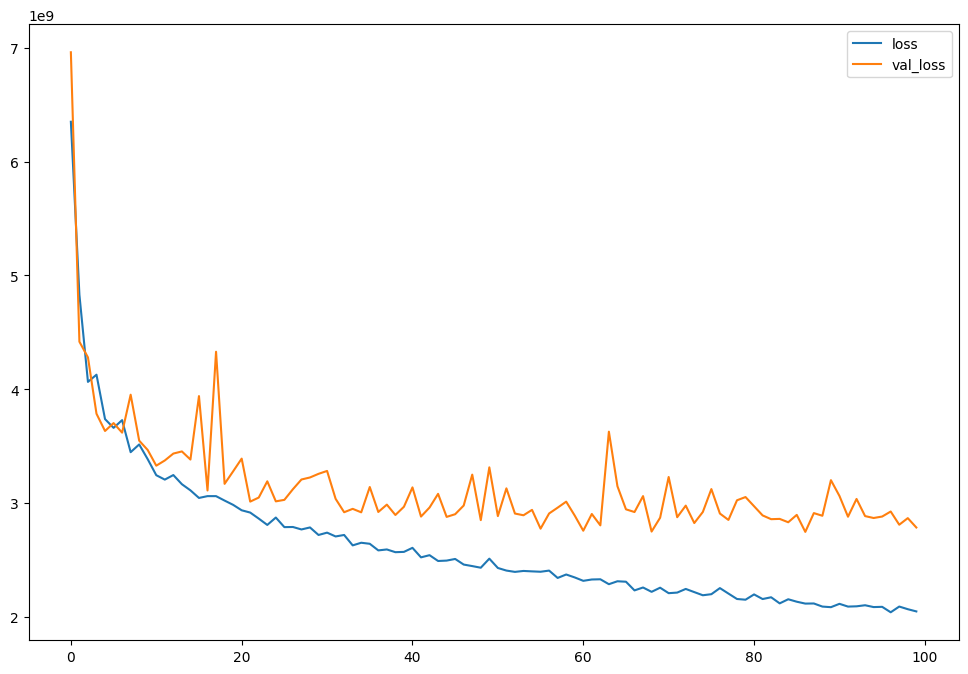

In [ ]:
loss_df = pd.DataFrame(model.history.history)
loss_df.plot(figsize=(12,8))

In [ ]:
y_pred = model.predict(X_test)

129/129 [==============================] - 0s 2ms/step


In [ ]:
# evaluation metrics
# explained variance score: best possible score is 1 and lower values are worse
from sklearn import metrics

print('Mean Absolute Error: {:.2f}'.format(metrics.mean_absolute_error(y_test, y_pred)))
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(y_test, y_pred)))
print('Root Mean Squared Error: {:.2f}'.format(np.sqrt(metrics.mean_squared_error(y_test, y_pred))))
print('Variance score is: {:.2f}'.format(metrics.explained_variance_score(y_test,y_pred)))

Mean Absolute Error: 35229.63
Mean Squared Error: 2784079872.94
Root Mean Squared Error: 52764.38
Variance score is: 0.79


In [ ]:
# we are off about 20% (comparing mean absolut error and mean of price)
ds['median_house_value'].mean()

206855.81690891474

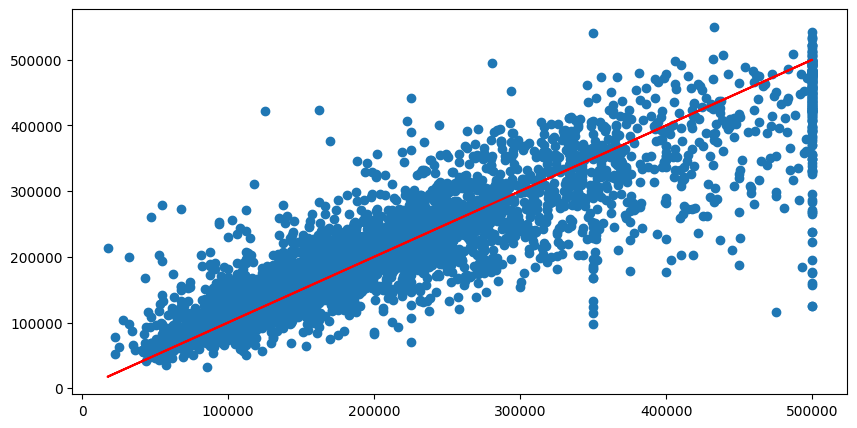

In [ ]:
# Our predictions
fig = plt.figure(figsize=(10,5))
plt.scatter(y_test,y_pred)
# Perfect predictions
plt.plot(y_test,y_test,'r')

In [ ]:
residuals = (y_test- y_pred)
residuals

array([[  41215.953125  , -153984.046875  , -137784.046875  , ...,
         -59484.046875  ,  -12984.046875  ,   61415.953125  ],
       [ 215532.50390625,   20332.50390625,   36532.50390625, ...,
         114832.50390625,  161332.50390625,  235732.50390625],
       [ 149797.1796875 ,  -45402.8203125 ,  -29202.8203125 , ...,
          49097.1796875 ,   95597.1796875 ,  169997.1796875 ],
       ...,
       [ 115435.515625  ,  -79764.484375  ,  -63564.484375  , ...,
          14735.515625  ,   61235.515625  ,  135635.515625  ],
       [  81028.15625   , -114171.84375   ,  -97971.84375   , ...,
         -19671.84375   ,   26828.15625   ,  101228.15625   ],
       [-112992.5625    , -308192.5625    , -291992.5625    , ...,
        -213692.5625    , -167192.5625    ,  -92792.5625    ]])

In [ ]:
dd=ds.copy()

In [ ]:
# let's drop price and keep first line featurs, then put those featur inside the model and estimae the price!
single_house = dd.drop('median_house_value',axis = 1).iloc[0]

In [ ]:
# need to apply featur scalling on those featurs
single_house = s_scaler.transform(single_house.values.reshape(-1,9))

In [ ]:
# apply model on those featurs
model.predict(single_house)

1/1 [==============================] - 0s 122ms/step


array([[374255.66]], dtype=float32)

In [ ]:
# compare the prediction with real price for the first column
dd['median_house_value'][0]


452600.0

In [ ]:
#CONCLUSION
#MLP:
#MAE 34844.68
#MSE 2830886128.04
#Variance 0.68

#LR:
#MAE 208768.49
#MSE 56960492003.37


#DNN:
#MAE 35310.88
#MSE 2776325486.53
#variance 0.79
#Learning rate=0.01 optimizer=Adam

#MLP (Multi-Layer Perceptron)

In [ ]:
 def build_mlp_model(input_dim):
    model = tensorflow.keras.models.Sequential([
        tensorflow.keras.layers.Dense(64, activation='relu', input_dim=input_dim),
        tensorflow.keras.layers.Dense(32, activation='relu'),
        tensorflow.keras.layers.Dense(1)  # Output layer for regression
    ])
    return model

# Build the MLP model
mlp_model = build_mlp_model(input_dim=X_train.shape[1])

# Compile the model
mlp_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
mlp_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/100
516/516 [==============================] - 5s 8ms/step - loss: 55629742080.0000 - val_loss: 55923232768.0000
Epoch 2/100
516/516 [==============================] - 2s 4ms/step - loss: 52062392320.0000 - val_loss: 49182392320.0000
Epoch 3/100
516/516 [==============================] - 2s 4ms/step - loss: 42300039168.0000 - val_loss: 36634468352.0000
Epoch 4/100
516/516 [==============================] - 2s 4ms/step - loss: 29288282112.0000 - val_loss: 23480942592.0000
Epoch 5/100
516/516 [==============================] - 1s 2ms/step - loss: 18446290944.0000 - val_loss: 14822378496.0000
Epoch 6/100
516/516 [==============================] - 1s 2ms/step - loss: 12697570304.0000 - val_loss: 11368524800.0000
Epoch 7/100
516/516 [==============================] - 1s 2ms/step - loss: 10613843968.0000 - val_loss: 10151664640.0000
Epoch 8/100
516/516 [==============================] - 2s 3ms/step - loss: 9666583552.0000 - val_loss: 9426635776.0000
Epoch 9/100
516/516 [=============

In [ ]:
mlp_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 64)                640       
                                                                 
 dense_7 (Dense)             (None, 32)                2080      
                                                                 
 dense_8 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2753 (10.75 KB)
Trainable params: 2753 (10.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


<Axes: >

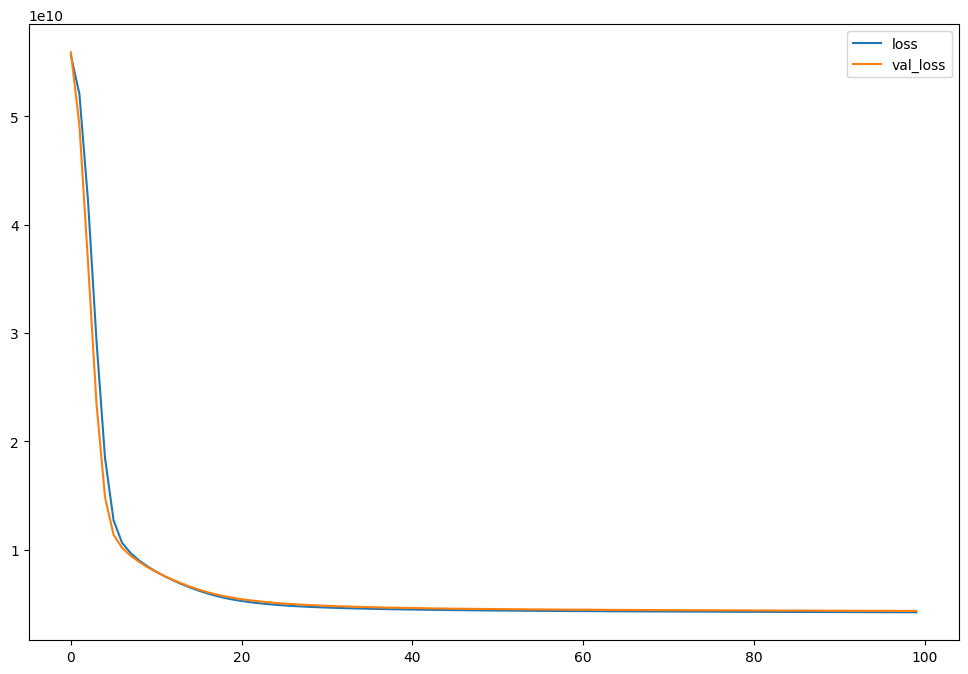

In [ ]:
loss_df = pd.DataFrame(mlp_model.history.history)
loss_df.plot(figsize=(12,8))

In [ ]:
# Evaluate MLP model
mlp_y_pred = mlp_model.predict(X_test)

129/129 [==============================] - 0s 1ms/step


In [ ]:
from sklearn import metrics
print('For Multi-Layer Perceptron (MLP):')
print('Mean Absolute Error: {:.2f}'.format(metrics.mean_absolute_error(y_test, mlp_y_pred)))
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(y_test, mlp_y_pred)))
print('Root Mean Squared Error: {:.2f}'.format(np.sqrt(metrics.mean_squared_error(y_test, mlp_y_pred))))
print('Variance score is: {:.2f}'.format(metrics.explained_variance_score(y_test,mlp_y_pred)))

For Multi-Layer Perceptron (MLP):
Mean Absolute Error: 46315.48
Mean Squared Error: 4337047634.79
Root Mean Squared Error: 65856.26
Variance score is: 0.68


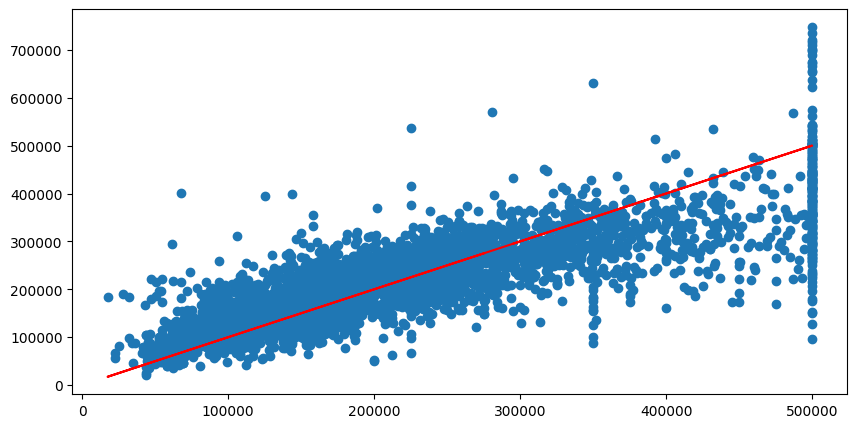

In [ ]:
# Our predictions
fig = plt.figure(figsize=(10,5))
plt.scatter(y_test,mlp_y_pred)
# Perfect predictions
plt.plot(y_test,y_test,'r')

#Linear Regression

In [ ]:
# Build the Linear Regression model
from sklearn.linear_model import LinearRegression
linear_model = tensorflow.keras.models.Sequential([
    tensorflow.keras.layers.Dense(1, input_dim=X_train.shape[1], activation='linear')
])

# Compile the model
linear_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
linear_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test,y_test))


Epoch 1/100
516/516 [==============================] - 2s 3ms/step - loss: 55883321344.0000 - val_loss: 56990142464.0000
Epoch 2/100
516/516 [==============================] - 1s 3ms/step - loss: 55883030528.0000 - val_loss: 56989843456.0000
Epoch 3/100
516/516 [==============================] - 1s 2ms/step - loss: 55882690560.0000 - val_loss: 56989548544.0000
Epoch 4/100
516/516 [==============================] - 1s 2ms/step - loss: 55882428416.0000 - val_loss: 56989253632.0000
Epoch 5/100
516/516 [==============================] - 1s 2ms/step - loss: 55882121216.0000 - val_loss: 56988942336.0000
Epoch 6/100
516/516 [==============================] - 1s 2ms/step - loss: 55881781248.0000 - val_loss: 56988651520.0000
Epoch 7/100
516/516 [==============================] - 1s 2ms/step - loss: 55881502720.0000 - val_loss: 56988348416.0000
Epoch 8/100
516/516 [==============================] - 1s 2ms/step - loss: 55881252864.0000 - val_loss: 56988045312.0000
Epoch 9/100
516/516 [===========

In [ ]:
linear_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 1)                 10        
                                                                 
Total params: 10 (40.00 Byte)
Trainable params: 10 (40.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Evaluate Linear Regression model
linear_y_pred = linear_model.predict(X_test)

129/129 [==============================] - 0s 1ms/step


In [ ]:
from sklearn import metrics
print('For Linear Regression:')
print('Mean Absolute Error: {:.2f}'.format(metrics.mean_absolute_error(y_test, linear_y_pred)))
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(y_test, linear_y_pred)))
print('Root Mean Squared Error: {:.2f}'.format(np.sqrt(metrics.mean_squared_error(y_test, linear_y_pred))))
print('Variance score is: {:.2f}'.format(metrics.explained_variance_score(y_test,linear_y_pred)))


For Linear Regression:
Mean Absolute Error: 208768.53
Mean Squared Error: 56960562706.59
Root Mean Squared Error: 238664.12
Variance score is: 0.00


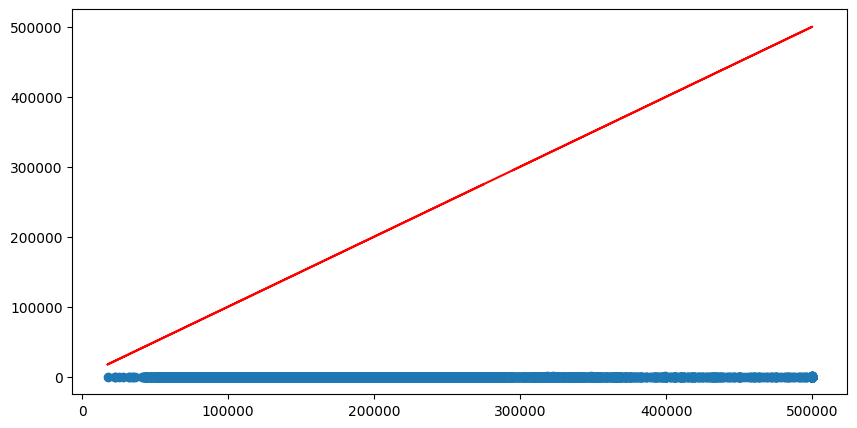

In [ ]:
# Our predictions
fig = plt.figure(figsize=(10,5))
plt.scatter(y_test,linear_y_pred)
# Perfect predictions
plt.plot(y_test,y_test,'r')

#DNN

In [ ]:
# having 10 nueron is based on the number of available featurs

model = Sequential()

model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam',loss='mse')

In [ ]:
model.fit(x=X_train,y=y_train,
          validation_data=(X_test,y_test),
          batch_size=32,epochs=100)

Epoch 1/100
516/516 [==============================] - 2s 2ms/step - loss: 7823230976.0000 - val_loss: 8049075712.0000
Epoch 2/100
516/516 [==============================] - 1s 2ms/step - loss: 7673906688.0000 - val_loss: 7912036352.0000
Epoch 3/100
516/516 [==============================] - 1s 2ms/step - loss: 7543452160.0000 - val_loss: 7787940352.0000
Epoch 4/100
516/516 [==============================] - 2s 4ms/step - loss: 7423319552.0000 - val_loss: 7671074816.0000
Epoch 5/100
516/516 [==============================] - 1s 3ms/step - loss: 7309689856.0000 - val_loss: 7560936448.0000
Epoch 6/100
516/516 [==============================] - 1s 2ms/step - loss: 7202470400.0000 - val_loss: 7456277504.0000
Epoch 7/100
516/516 [==============================] - 1s 3ms/step - loss: 7099316736.0000 - val_loss: 7354507264.0000
Epoch 8/100
516/516 [==============================] - 1s 3ms/step - loss: 6998937600.0000 - val_loss: 7253995520.0000
Epoch 9/100
516/516 [===========================

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                100       
                                                                 
 dense_1 (Dense)             (None, 10)                110       
                                                                 
 dense_2 (Dense)             (None, 1)                 11        
                                                                 
Total params: 221 (884.00 Byte)
Trainable params: 221 (884.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


<Axes: >

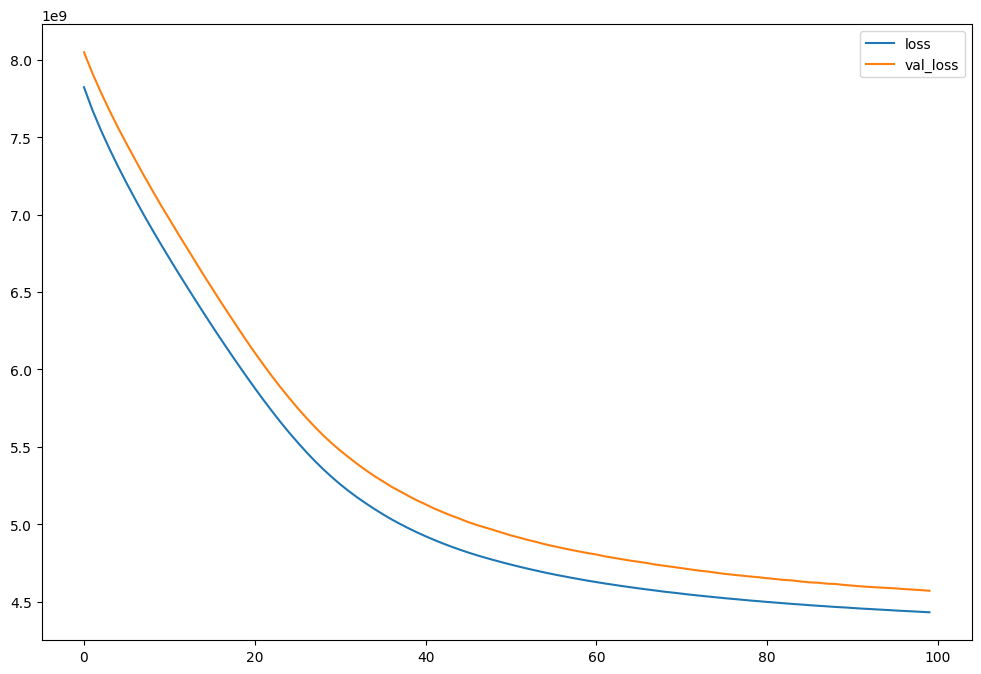

In [ ]:
loss_df = pd.DataFrame(model.history.history)
loss_df.plot(figsize=(12,8))

In [ ]:
y_pred = model.predict(X_test)

129/129 [==============================] - 0s 2ms/step


In [ ]:
# evaluation metrics
# explained variance score: best possible score is 1 and lower values are worse
from sklearn import metrics

print('Mean Absolute Error: {:.2f}'.format(metrics.mean_absolute_error(y_test, y_pred)))
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(y_test, y_pred)))
print('Root Mean Squared Error: {:.2f}'.format(np.sqrt(metrics.mean_squared_error(y_test, y_pred))))
print('Variance score is: {:.2f}'.format(metrics.explained_variance_score(y_test,y_pred)))


Mean Absolute Error: 47796.48
Mean Squared Error: 4570169656.06
Root Mean Squared Error: 67603.03
Variance score is: 0.66


In [ ]:
# we are off about 20% (comparing mean absolut error and mean of price)
ds['median_house_value'].mean()

206855.81690891474

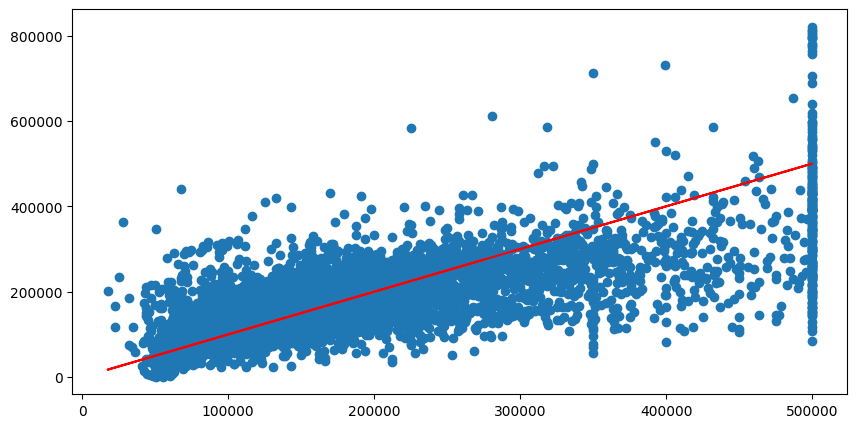

In [ ]:
# Our predictions
fig = plt.figure(figsize=(10,5))
plt.scatter(y_test,y_pred)
# Perfect predictions
plt.plot(y_test,y_test,'r')

In [ ]:
fig = plt.figure(figsize=(10,5))
residuals = (y_test- y_pred)
sns.displot(residuals)

Exception ignored in: <function _xla_gc_callback at 0x7bf82955c160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/jax/_src/lib/__init__.py", line 97, in _xla_gc_callback
    def _xla_gc_callback(*args):
KeyboardInterrupt: 


In [ ]:
# let's drop price and keep first line featurs, then put those featur inside the model and estimae the price!
single_house = Data.drop('price',axis = 1).iloc[0]

In [ ]:
# need to apply featur scalling on those featurs
single_house = s_scaler.transform(single_house.values.reshape(-1,19))

In [ ]:
# apply model on those featurs
model.predict(single_house)

In [ ]:
# compare the prediction with real price for the first column
Data['price'][0]
